# Data

> Data classes and functions

In [ ]:
#| default_exp data.core

In [ ]:
#| hide
from nbdev.showdoc import *
from fastcore.test import *

In [ ]:
#| export

# =================================
# Standard library
# =================================
from plum import dispatch



# =================================
# fastai
# =================================
from fastai.torch_core import TensorImage, TensorCategory, TensorMultiCategory
from fastai.vision.all import TransformBlock, Categorize

# =================================
# bioMONAI
# =================================
from bioMONAI.utils import *
from bioMONAI.io import image_reader, image_reader_dict
from bioMONAI.visualize import show_biodata, show_multichannel

# =================================
# fasttransform patch
# =================================
import fasttransform

_original_repr = fasttransform.transform.Transform.__repr__

def _safe_repr(self):
    try:
        return _original_repr(self)
    except AttributeError as e:
        if "'_BoundFunction' object has no attribute 'methods'" in str(e):
            return f"{self.__class__.__name__}(...)"
        raise

fasttransform.transform.Transform.__repr__ = _safe_repr

## Data types

The module introduces specialized classes to represent various bioimaging data structures, facilitating seamless integration with machine learning workflows.

In [ ]:
#| export

class MetaResolver(type(torchTensor), metaclass=BypassNewMeta):
    """
    The `MetaResolver` class addresses metaclass conflicts, ensuring compatibility across different data structures. This is particularly useful when integrating with libraries that have specific metaclass requirements.
    """
    pass
    

In [ ]:
#| export
class BioDataClass(MetaTensor):
    """
    Base class for bioMONAI data.
    """

    _transforms = None
    _keys = []

    # --------------------------------------------------
    # BASIC CONSTRUCTORS
    # --------------------------------------------------
    @classmethod
    def from_tensor(cls, x: torchTensor, meta: dict | None = None):
        return cls(x=x, meta=meta or {})
    
    @classmethod
    def from_metatensor(cls, x: MetaTensor):
        return cls(x=x.data, meta=x.meta)
    
    # --------------------------------------------------
    # TRANSFORMS
    # --------------------------------------------------
    @classmethod
    def set_transforms(cls, transforms):
        cls._transforms = transforms
    
    # --------------------------------------------------
    # GET DATA LOADERS
    # --------------------------------------------------
    @classmethod
    def get_loader(cls,**kwargs) -> Callable:
        raise NotImplementedError("Subclasses must implement the `get_loader` method to define how to load data.")

    @classmethod
    def get_dict_loader(cls, **kwargs) -> Callable:
        raise NotImplementedError("Subclasses must implement the `get_dict_loader` method to define how to load data.")
    
    # --------------------------------------------------
    # LOADING
    # --------------------------------------------------
    @classmethod
    def from_source(cls, x, **kwargs):
        raise NotImplementedError("Subclasses must implement the `create` method to define how to instantiate from raw data.")
    
    @classmethod
    def from_dict(cls, x:dict, keys:str|Iterable[str]=None, **kwargs):
        raise NotImplementedError("Subclasses must implement the `create` method to define how to instantiate from raw data.")
    
    # --------------------------------------------------
    # CREATE DATABLOCK (fastai integration)
    # --------------------------------------------------
    @classmethod
    def get_datablock(cls):
        return TransformBlock(type_tfms=[cls.from_source])

    # --------------------------------------------------
    # REPR
    # --------------------------------------------------
    def __repr__(self) -> str:
        return f"{self.__class__.__name__}{self.as_tensor().__repr__()[6:]}"

In [ ]:
torchTensor([1,2,3]).as_subclass(BioDataClass)

BioDataClass([1., 2., 3.])

In [ ]:
BioDataClass.from_metatensor(MetaTensor(x=[1, 2, 3],meta={"a": 1})).meta

{'a': 1,
 affine: tensor([[1., 0., 0., 0.],
         [0., 1., 0., 0.],
         [0., 0., 1., 0.],
         [0., 0., 0., 1.]], dtype=torch.float64),
 space: RAS}

In [ ]:
BioDataClass([]).as_tensor()

tensor([])

In [ ]:
BioDataClass([1,2,3]).__repr__()

'BioDataClass([1, 2, 3])'

### Images

**BioImageBase** is a function that acts as a base class for biomedical images. It can be used for many things, such as loading image data as PyTorch tensors, displaying 2D slices of 3D images and making transformations on medical images. 

In [ ]:
#| export
class BioImageBase(BioDataClass, TensorImage, metaclass=MetaResolver):
    """
    Base class for bioimaging data.

    Provides:
    - MetaTensor integration
    - visualization utilities
    - lightweight tensor wrapper

    """

    _bypass_type = torchTensor
    _show_args = {"cmap": "gray"}
    _channels = "CZYX"
    _output = 'metatensor'
    _transforms = None
    _keys = ['image']

    # --------------------------------------------------
    # LOADING
    # --------------------------------------------------
    @classmethod
    def from_source(cls, x, **kwargs):
        metatensor = cls.get_loader(**kwargs)(x)
        return cls(metatensor.data, meta=metatensor.meta)
    
    @classmethod
    def from_dict(cls, x:dict, keys:str|Iterable[str]=None, **kwargs):
        if keys is None:
            keys = []

        metatensor_dict = cls.get_dict_loader(keys=keys, **kwargs)(x)

        if isinstance(keys, str):
            keys = [keys]

        for key in keys:
            if key in metatensor_dict:
                x = metatensor_dict[key]
                metatensor_dict[key] = cls(x.data, meta=x.meta)

        return metatensor_dict
    
    # --------------------------------------------------
    # MONAI INTEGRATION
    # --------------------------------------------------
    @classmethod
    def get_loader(cls,**kwargs) -> Callable:
        def _load(x):
            if isinstance(x, torchTensor):
                return cls.from_tensor(x)

            local_kwargs = dict(kwargs)
            local_kwargs.setdefault("output", cls._output)
            local_kwargs.setdefault("channels", cls._channels)
            local_kwargs.setdefault("transforms", cls._transforms)

            return image_reader(
                x,
                **local_kwargs,
            )

        return _load

    @classmethod
    def get_dict_loader(cls, **kwargs) -> Callable:
        def _load_dict(data: dict):

            local_kwargs = dict(kwargs)
            local_kwargs.setdefault("keys", cls._keys)
            local_kwargs.setdefault("output", cls._output)
            local_kwargs.setdefault("channels", cls._channels)
            local_kwargs.setdefault("transforms", cls._transforms)

            return image_reader_dict(
                data,
                **local_kwargs,
            )

        return _load_dict
    
    # --------------------------------------------------
    # VISUALIZATION
    # --------------------------------------------------
    def show(self, ctx=None, figsize=None, title=None, **kwargs):
        return show_biodata(
            self,
            ctx=ctx,
            title=title if title is not None else None,
            volume_mode='grid',
            figsize=figsize,
            **merge(self._show_args, kwargs),
        )
    

In [ ]:
BioImageBase(torchTensor([1, 2, 3])).__repr__()

'BioImageBase([1., 2., 3.])'

In [ ]:
BioImageBase.get_dict_loader(keys=['image'], channels="YX")({'image': './data_examples/example_tiff.tiff'})

/home/bm/miniforge3/envs/biomonai_latest/lib/python3.11/site-packages/bioio_tifffile/reader.py:164: UserWarning: Could not parse tiff pixel size: 'ResolutionUnit'
  warnings.warn(f"Could not parse tiff pixel size: {e}")


{'image': metatensor([[133., 133., 133.,  ..., 133., 133., 132.],
         [133., 133., 133.,  ..., 133., 133., 133.],
         [133., 133., 134.,  ..., 133., 133., 133.],
         ...,
         [133., 133., 133.,  ..., 133., 133., 133.],
         [133., 133., 133.,  ..., 133., 133., 133.],
         [133., 133., 134.,  ..., 133., 132., 133.]])}

In [ ]:
a_dict = BioImageBase.from_dict({'image': './data_examples/example_tiff.tiff'}, keys='image', channels="YX")
test_eq(type(a_dict), dict)
test_eq(type(a_dict['image']), BioImageBase)
a_dict

{'image': BioImageBase([[133., 133., 133.,  ..., 133., 133., 132.],
         [133., 133., 133.,  ..., 133., 133., 133.],
         [133., 133., 134.,  ..., 133., 133., 133.],
         ...,
         [133., 133., 133.,  ..., 133., 133., 133.],
         [133., 133., 133.,  ..., 133., 133., 133.],
         [133., 133., 134.,  ..., 133., 132., 133.]])}

In [ ]:
a = BioImageBase.from_source('./data_examples/example_tiff.tiff', channels="YX")
test_eq(a.shape, a.meta['size_output'])
test_shuffled(a_dict['image'].meta.keys(), a.meta.keys())
# a.meta

In [ ]:
a = BioImageBase.from_source('./data_examples/example_tiff.tiff')
print(a.shape)
print(type(a).__name__)
a.meta

torch.Size([1, 96, 512, 512])
BioImageBase


{'channel_names': ['Channel:0:0'],
 'current_resolution_level': 0,
 'current_scene': 'Image:0',
 'current_scene_index': 0,
 'dimension_properties': [[None, None],
  [None, None],
  [None, None],
  [None, None],
  [None, None]],
 'dims': {'T': 1, 'C': 1, 'Z': 96, 'Y': 512, 'X': 512},
 'dtype': 'uint8',
 'metadata': {256: 512,
  257: 512,
  258: 8,
  259: <COMPRESSION.NONE: 1>,
  262: <PHOTOMETRIC.MINISBLACK: 1>,
  273: [8],
  274: <ORIENTATION.TOPLEFT: 1>,
  277: 1,
  278: 512,
  279: [262144],
  284: <PLANARCONFIG.CONTIG: 1>,
  339: <SAMPLEFORMAT.UINT: 1>},
 'mosaic_tile_dims': None,
 'ome_metadata': '<error: >',
 'physical_pixel_sizes': [None, None, None],
 'reader': {'chunk_dims': ['Z', 'Y', 'X', 'S']},
 'resolution_level_dims': {0: [96, 512, 512]},
 'resolution_levels': [0],
 'scale': [None, None, None, None, None],
 'scenes': ['Image:0'],
 'shape': [1, 1, 96, 512, 512],
 'standard_metadata': {'binning': None,
  'column': None,
  'dimensions_present': 'ZYX',
  'image_size_c': None,


The load method returns a pure MetaTensor instead of a BioImageBase instance

In [ ]:
a = BioImageBase.get_loader()('./data_examples/example_tiff.tiff') 
print(a.shape)
print(type(a).__name__)
a.meta

torch.Size([1, 96, 512, 512])
MetaTensor


{'channel_names': ['Channel:0:0'],
 'current_resolution_level': 0,
 'current_scene': 'Image:0',
 'current_scene_index': 0,
 'dimension_properties': [[None, None],
  [None, None],
  [None, None],
  [None, None],
  [None, None]],
 'dims': {'T': 1, 'C': 1, 'Z': 96, 'Y': 512, 'X': 512},
 'dtype': 'uint8',
 'metadata': {256: 512,
  257: 512,
  258: 8,
  259: <COMPRESSION.NONE: 1>,
  262: <PHOTOMETRIC.MINISBLACK: 1>,
  273: [8],
  274: <ORIENTATION.TOPLEFT: 1>,
  277: 1,
  278: 512,
  279: [262144],
  284: <PLANARCONFIG.CONTIG: 1>,
  339: <SAMPLEFORMAT.UINT: 1>},
 'mosaic_tile_dims': None,
 'ome_metadata': '<error: >',
 'physical_pixel_sizes': [None, None, None],
 'reader': {'chunk_dims': ['Z', 'Y', 'X', 'S']},
 'resolution_level_dims': {0: [96, 512, 512]},
 'resolution_levels': [0],
 'scale': [None, None, None, None, None],
 'scenes': ['Image:0'],
 'shape': [1, 1, 96, 512, 512],
 'standard_metadata': {'binning': None,
  'column': None,
  'dimensions_present': 'ZYX',
  'image_size_c': None,


In [ ]:
a = BioImageBase.get_dict_loader(keys=['image'])({'image': './data_examples/example_tiff.tiff'}) 
print(a['image'].shape)
print(type(a).__name__)
a['image'].meta

torch.Size([1, 96, 512, 512])
dict


{'channel_names': ['Channel:0:0'],
 'current_resolution_level': 0,
 'current_scene': 'Image:0',
 'current_scene_index': 0,
 'dimension_properties': [[None, None],
  [None, None],
  [None, None],
  [None, None],
  [None, None]],
 'dims': {'T': 1, 'C': 1, 'Z': 96, 'Y': 512, 'X': 512},
 'dtype': 'uint8',
 'metadata': {256: 512,
  257: 512,
  258: 8,
  259: <COMPRESSION.NONE: 1>,
  262: <PHOTOMETRIC.MINISBLACK: 1>,
  273: [8],
  274: <ORIENTATION.TOPLEFT: 1>,
  277: 1,
  278: 512,
  279: [262144],
  284: <PLANARCONFIG.CONTIG: 1>,
  339: <SAMPLEFORMAT.UINT: 1>},
 'mosaic_tile_dims': None,
 'ome_metadata': '<error: >',
 'physical_pixel_sizes': [None, None, None],
 'reader': {'chunk_dims': ['Z', 'Y', 'X', 'S']},
 'resolution_level_dims': {0: [96, 512, 512]},
 'resolution_levels': [0],
 'scale': [None, None, None, None, None],
 'scenes': ['Image:0'],
 'shape': [1, 1, 96, 512, 512],
 'standard_metadata': {'binning': None,
  'column': None,
  'dimensions_present': 'ZYX',
  'image_size_c': None,


It is possible to load only an ROI, which should be indicated by using an index dictionary.

BioImageBase
torch.Size([1, 300, 512])


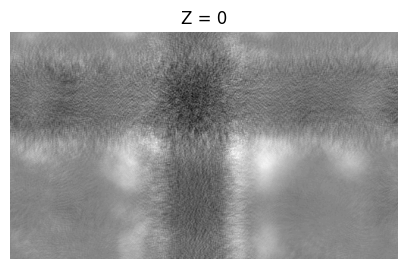

In [ ]:
imagebase_2d = BioImageBase.from_source('./data_examples/example_tiff.tiff', channels="CYX", ind_dict={'Z': 0, 'Y': slice(0, 300)})  
print((type(imagebase_2d)).__name__) 
print(imagebase_2d.shape)
imagebase_2d.show(title="Z = 0", figsize=(5, 5));

BioImageBase
torch.Size([10, 300, 512])


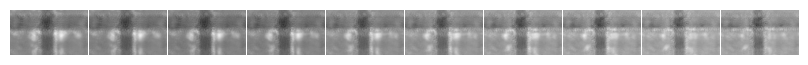

In [ ]:
imagebase_3d = BioImageBase.from_source('./data_examples/example_tiff.tiff', channels="ZYX", ind_dict={'Z': range(10), 'Y': slice(0, 300)})  
print((type(imagebase_3d)).__name__) 
print(imagebase_3d.shape)
imagebase_3d.show();

**BioImage** is a specialization of BioImageBase that is specifically used for 2D and 3D biomedical images. To do so, it directly inherits from that class and then squeezes the image data and allows for transformations to be made there.

In [ ]:
#| export
class BioImage(BioImageBase):
    """
    Tensor-backed bioimage loaded from disk.
    """

    _channels = "CYX"


BioImage


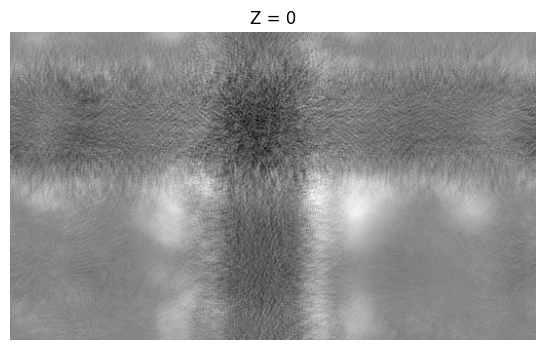

In [ ]:
image_2d = BioImage.from_source('./data_examples/example_tiff.tiff', ind_dict={'Z': 0, 'Y': slice(0, 300)}) 
print((type(image_2d)).__name__) 
test_eq(imagebase_2d, image_2d)
image_2d.show(title="Z = 0");

In [ ]:
image_2d = BioImage.get_loader(ind_dict={'Z': 0, 'Y': slice(0, 300)})('./data_examples/example_tiff.tiff')  
print((type(image_2d)).__name__)
test_eq(imagebase_2d, image_2d)

MetaTensor


In [ ]:
#| export
class BioVolume(BioImageBase):
    """
    Tensor-backed volume loaded from disk.

    """

    _channels="CZYX"


BioVolume
torch.Size([1, 10, 300, 512])


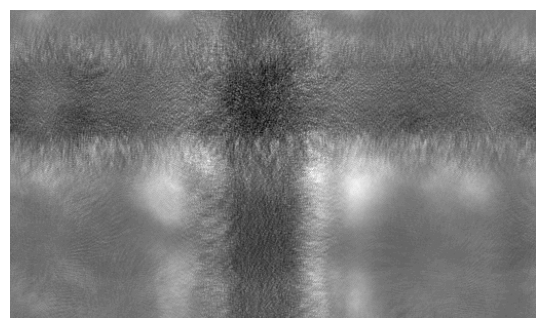

In [ ]:
image_3d = BioVolume.from_source('./data_examples/example_tiff.tiff', ind_dict={'Z': range(10), 'Y': slice(0, 300)})  
print((type(image_3d)).__name__)
print(image_3d.shape)
test_eq(imagebase_3d, image_3d[0])
image_3d.show();

In [ ]:
image_3d = BioVolume.get_loader(ind_dict={'Z': range(10), 'Y': slice(0, 300)}, channels="ZYX")('./data_examples/example_tiff.tiff')  
print(image_3d.shape)
test_eq(imagebase_3d, image_3d)

torch.Size([10, 300, 512])


In [ ]:
#| export
def _mip_transform(cls, img, layout):
    z_dim = layout.index("Z")

    mip = torchmax(img.as_tensor(), dim=z_dim).values

    meta = dict(img.meta)
    meta["layout"] = layout.replace("Z", "")
    meta["size_output"] = tuple(mip.shape)

    return cls(x=mip, meta=meta)

In [ ]:
#| hide
class BioMIP(BioImageBase):
    """
    The `BioImageProject` class represents a 3D image stack as a 2D image using maximum intensity projection. This is particularly useful for visualizing volumetric data in a 2D format, aiding in quick assessments and presentations.
    """
    
    _show_args = {"cmap": "gray"}
    _channels = "CZYX"
    _channel_modes = {1: "L", 3: "RGB", 4: "RGBA"}

    @classmethod
    def _get_layout(cls, img, kwargs):
        return img.meta.get("layout") or kwargs.get("channels") or cls._channels

    @classmethod
    def from_source(cls, x, keys=None, **kwargs):
        kwargs.setdefault("channels", cls._channels)

        is_dict_input = isinstance(x, dict) or (
            isinstance(x, Sequence)
            and x
            and isinstance(x[0], dict)
        )

        if is_dict_input:
            out = super(cls, cls).from_source(
                x,
                keys=keys,
                **kwargs,
            )

            if keys is None:
                keys = []

            if isinstance(keys, str):
                keys = [keys]

            layout = kwargs.get("channels")

            for key in keys:
                img = out[key]
                out[key] = _mip_transform(cls, img, layout)

            return out

        img = super(cls, cls).from_source(x, **kwargs)

        layout = kwargs.get("channels")

        return _mip_transform(cls, img, layout)


torch.Size([1, 512, 512])


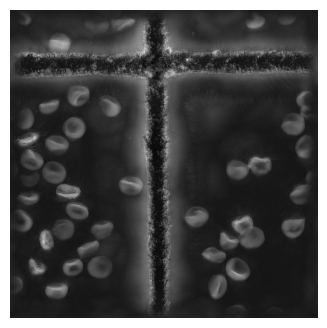

In [ ]:
image_mip = BioMIP.from_source('./data_examples/example_tiff.tiff')  
print(image_mip.shape)
# test_eq(imagebase_mip, image_mip)
image_mip.show();

In [ ]:
image_mip.meta

{'channel_names': ['Channel:0:0'],
 'current_resolution_level': 0,
 'current_scene': 'Image:0',
 'current_scene_index': 0,
 'dimension_properties': [[None, None],
  [None, None],
  [None, None],
  [None, None],
  [None, None]],
 'dims': {'T': 1, 'C': 1, 'Z': 96, 'Y': 512, 'X': 512},
 'dtype': 'uint8',
 'metadata': {256: 512,
  257: 512,
  258: 8,
  259: <COMPRESSION.NONE: 1>,
  262: <PHOTOMETRIC.MINISBLACK: 1>,
  273: [8],
  274: <ORIENTATION.TOPLEFT: 1>,
  277: 1,
  278: 512,
  279: [262144],
  284: <PLANARCONFIG.CONTIG: 1>,
  339: <SAMPLEFORMAT.UINT: 1>},
 'mosaic_tile_dims': None,
 'ome_metadata': '<error: >',
 'physical_pixel_sizes': [None, None, None],
 'reader': {'chunk_dims': ['Z', 'Y', 'X', 'S']},
 'resolution_level_dims': {0: [96, 512, 512]},
 'resolution_levels': [0],
 'scale': [None, None, None, None, None],
 'scenes': ['Image:0'],
 'shape': [1, 1, 96, 512, 512],
 'standard_metadata': {'binning': None,
  'column': None,
  'dimensions_present': 'ZYX',
  'image_size_c': None,


In [ ]:
#| export
class BioVideo(BioImageBase):
    """
    Tensor-backed video loaded from disk.

    This is the class that:
    - uses image_reader
    - handles transforms
    - returns MetaTensor-backed images
    """

    _channels="CTYX"
    

In [ ]:
#| export
class BioMultiChannel(BioImageBase):
    """
    Multi-channel 2D/3D image assuming CZYX layout.
    """

    @classmethod
    def _apply_mip(cls, tensor, merge_cd, interleaved, **kwargs):
            layout = (
                kwargs.get("layout")
                or getattr(tensor, "meta", {}).get("layout")
                or cls._channels
            )

            if not merge_cd:
                if hasattr(tensor, "meta"):
                    tensor.meta["layout"] = layout
                    tensor.meta["size_output"] = tuple(tensor.shape)
                return tensor

            if layout is None or "C" not in layout or "Z" not in layout:
                raise ValueError(
                    f"BioMultiChannel merge_cd requires C and Z axes, got {layout!r}"
                )

            c_dim = layout.index("C")
            z_dim = layout.index("Z")

            c = tensor.shape[c_dim]
            d = tensor.shape[z_dim]

            spatial_dims = [i for i in range(tensor.ndim) if i not in (c_dim, z_dim)]

            if interleaved:
                permute_dims = [z_dim, c_dim, *spatial_dims]
            else:
                permute_dims = [c_dim, z_dim, *spatial_dims]

            tensor = tensor.permute(*permute_dims)
            tensor = tensor.reshape(c * d, *tensor.shape[2:])

            output_layout = layout.replace("Z", "")

            if hasattr(tensor, "meta"):
                tensor.meta["layout"] = output_layout
                tensor.meta["size_output"] = tuple(tensor.shape)

            return tensor
    
    @classmethod
    def from_source(
        cls,
        x: PathLike | Sequence[PathLike] | torchTensor,
        keys=None,
        merge_cd: bool = True,
        interleaved: bool = True,
        **kwargs,
    ):
        kwargs.setdefault("channels", cls._channels)

        out = super().from_source(x, keys=keys, **kwargs)

        if isinstance(out, dict):
            return {k: cls._apply_mip(v, merge_cd=merge_cd, interleaved=interleaved, **kwargs) for k, v in out.items()}

        return cls._apply_mip(out, merge_cd=merge_cd, interleaved=interleaved, **kwargs)

    def show(self, ctx=None, **kwargs):
        return show_multichannel(self, ctx=ctx, **merge(self._show_args, kwargs))



Layout: CYX


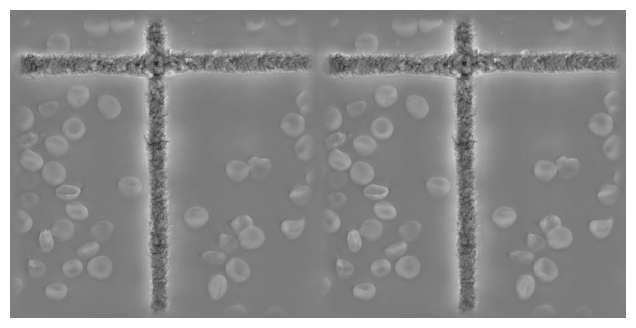

In [ ]:
image_mlt = BioMultiChannel.from_source('./data_examples/example_tiff.tiff')  
test_eq(image_mlt.shape, [96, 512, 512])
image_mlt.show();
print('Layout:', image_mlt.meta['layout'])

### Categorical

In [ ]:
#| export
class BioLabel(BioDataClass):
    """
    Data class for Categorical data.

    """

    _keys = ['label']
    _vocab = None
    _sort = True
    _add_na = False

    # --------------------------------------------------
    # LOADING
    # --------------------------------------------------
    @classmethod
    def from_source(cls, x, **kwargs):
        cat = cls.get_loader(**kwargs)
        return cat(x)
    
    @classmethod
    def from_dict(cls, x:dict, keys:str|Iterable[str]=None, **kwargs):
        cat = cls.get_dict_loader(keys=keys, **kwargs)
        return cat(x)
    
    # --------------------------------------------------
    # MONAI INTEGRATION
    # --------------------------------------------------
    @classmethod
    def get_loader(cls,**kwargs) -> Callable:

        vocab = kwargs.get('vocab', cls._vocab)
        sort = kwargs.get('sort', cls._sort)
        add_na = kwargs.get('add_na', cls._add_na)

        cat = Categorize(vocab=vocab, sort=sort, add_na=add_na)

        return cat

    @classmethod
    def get_dict_loader(cls, **kwargs) -> Callable:

        vocab = kwargs.get('vocab', cls._vocab)
        sort = kwargs.get('sort', cls._sort)
        add_na = kwargs.get('add_na', cls._add_na)
        keys = kwargs.get("keys", cls._keys)

        cat = Categorize(vocab=vocab, sort=sort, add_na=add_na)
        
        def _load_dict(data: dict):
            out = data.copy()
            for key in keys:
                out[key] = cat(data[key])
            return out

        return _load_dict

    
    

In [ ]:
t = BioLabel.get_loader(vocab=['b', 'a', 'a', 'a', 'c'])


In [ ]:
print(t.vocab)
t.decode(1)

['a', 'b', 'c']


'b'

In [ ]:
t('b')

TensorCategory(1)

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()